In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500,2010,6
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500,2010,6
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000,2010,7
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000,2010,7
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500,2010,7


In [4]:
# Daily returns
df["Daily Return"] = df["Close"].pct_change()

# Moving averages
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Daily Return,MA50,MA200
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500,2010,6,NaN,NaN,NaN
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500,2010,6,-0.002512,NaN,NaN
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000,2010,7,-0.078473,NaN,NaN
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000,2010,7,-0.125683,NaN,NaN
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500,2010,7,-0.160937,NaN,NaN


In [5]:
# stats

print("Max Price:", np.max(df["Close"]))
print("Min Price:", np.min(df["Close"]))
print("Average Price:", np.mean(df["Close"]))
print("Volatility:", np.std(df["Daily Return"]))

Max Price: 1229.910034
Min Price: 3.16
Average Price: 138.7621830964141
Volatility: 0.035593879208294855


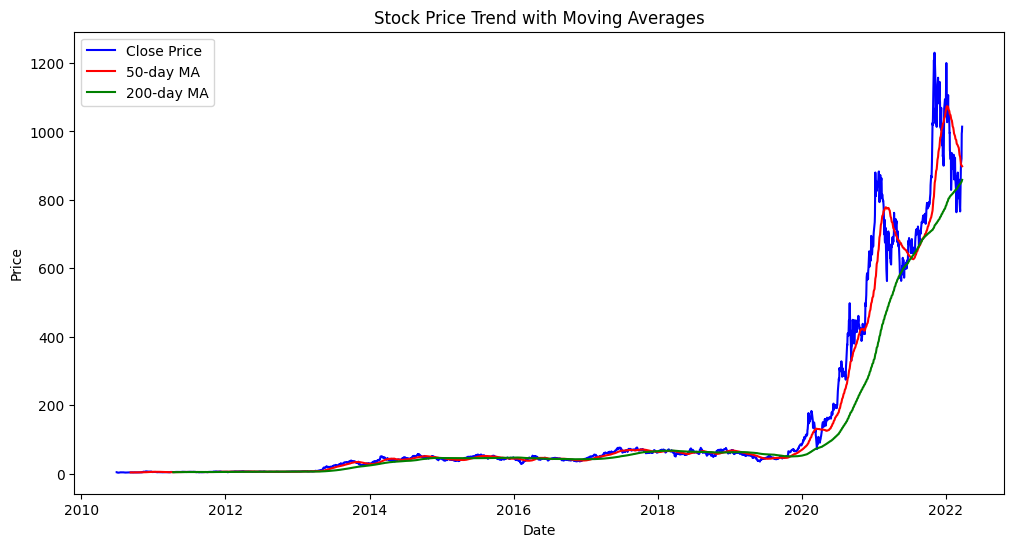

In [6]:
# Line chart: Closing price trend

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close Price", color="blue")
plt.plot(df["Date"], df["MA50"], label="50-day MA", color="red")
plt.plot(df["Date"], df["MA200"], label="200-day MA", color="green")
plt.title("Stock Price Trend with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

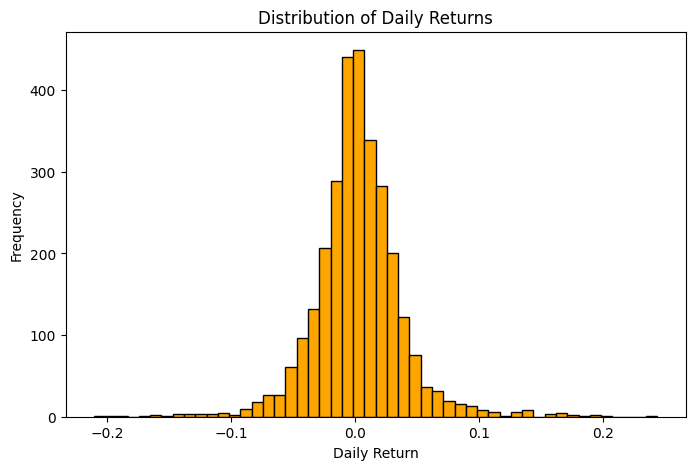

In [7]:
# Histogram: Daily returns

plt.figure(figsize=(8,5))
plt.hist(df["Daily Return"].dropna(), bins=50, color="orange", edgecolor="black")
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

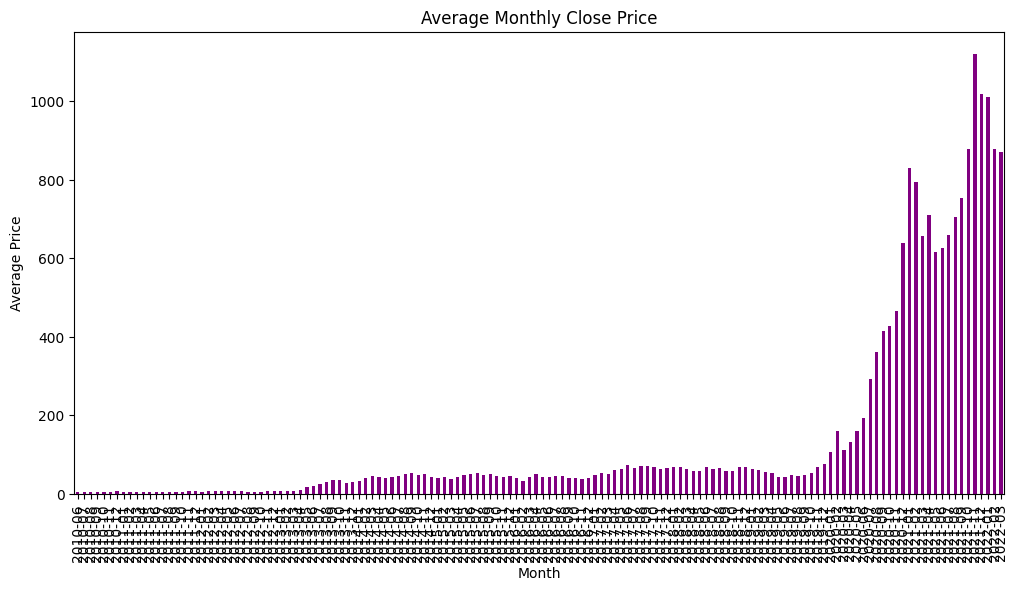

In [8]:
# Bar chart: Monthly average close price

df["Month"] = df["Date"].dt.to_period("M")
monthly_avg = df.groupby("Month")["Close"].mean()

monthly_avg.plot(kind="bar", figsize=(12,6), color="purple")
plt.title("Average Monthly Close Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.show()

In [9]:
df.to_csv("stocks_cleaned.csv", index=False)